In [27]:
import pandas as pd
df = pd.read_csv("C:/Users/Hp/Downloads/P9-OLTP.csv")  

# Quick look at the data
print(df.head())
print(df.info())

   TransactionID       Date      Time  CustomerID     Name  Surname  \
0         113255  13-Dec-16  18:05:00   200000663  Leonard  Jackson   
1         113254  13-Dec-16  18:05:00   200000661    Lucas  Abraham   
2         113253  13-Dec-16  18:03:00   200000662   Trevor  Skinner   
3         113252  13-Dec-16  18:01:00   100000007  Dorothy  Thomson   
4         113251  13-Dec-16  18:01:00   400000180     Eric    Bower   

  Shipping_State    Item No.       Description  Retail_Price   \
0       Delaware  8619953091        Pillowcase          18.96   
1      Louisiana  2020397001  Men's Pajama Set          23.10   
2      Louisiana  4681342313            Sheets          29.90   
3        Alabama  6697166886              Coat         159.80   
4  New Hampshire  6697166886              Coat         159.80   

   Loyalty_Discount  
0              0.02  
1              0.00  
2              0.10  
3              0.07  
4              0.06  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 

In [10]:
# To check data quality and consistency
print("Missing values:\n", df.isnull().sum())
print("----------------------")
print("Duplicate rows:", df.duplicated().sum())

Missing values:
 TransactionID       0
Date                0
Time                0
CustomerID          0
Name                0
Surname             0
Shipping_State      0
Item No.            0
Description         0
Retail_Price        0
Loyalty_Discount    0
Net_Price           0
Day                 0
Hour                0
dtype: int64
----------------------
Duplicate rows: 0


In [29]:
# To do Basic statistics
df.describe()

,TransactionID,CustomerID,Item No.,Retail_Price,Loyalty_Discount
count,3455.000000,3.455000e+03,3.455000e+03,3455.000000,3455.000000
mean,111528.000000,1.797979e+08,5.276712e+09,58.526237,0.050457
std,997.516917,9.563412e+07,2.600486e+09,34.464217,0.032215
min,109801.000000,1.000000e+08,1.039855e+09,5.600000,0.000000
25%,110664.500000,1.000003e+08,2.963301e+09,31.800000,0.020000
50%,111528.000000,1.000009e+08,5.145202e+09,51.660000,0.050000
75%,112391.500000,2.000009e+08,7.645689e+09,79.800000,0.080000
max,113255.000000,4.000009e+08,9.916068e+09,159.800000,0.100000


In [30]:
# To calculate the number of unique values
df['CustomerID'].nunique()

942

In [34]:
# To list all the unique values
df['CustomerID'].unique()

array([200000663, 200000661, 200000662, 100000007, 400000180, 200000701,
       300000467, 400000706, 100000061, 400000513, 200000459, 200000482,
       100000081, 200000821, 300000015, 100000252, 300000822, 300000815,
       100000618, 100000051, 100000880, 100000898, 400000359, 100000559,
       100000878, 100000013, 100000569, 300000852, 100000158, 300000023,
       100000923, 100000251, 400000557, 300000614, 100000477, 200000537,
       100000567, 200000256, 400000368, 100000521, 200000493, 100000173,
       100000824, 100000344, 100000760, 100000542, 300000730, 100000121,
       200000582, 400000396, 300000238, 100000236, 100000010, 100000341,
       100000564, 400000690, 200000387, 400000916, 100000931, 100000345,
       100000144, 300000495, 100000169, 300000702, 100000383, 200000646,
       400000398, 100000192, 100000315, 100000181, 300000814, 100000854,
       100000286, 200000548, 100000145, 100000412, 200000350, 100000724,
       400000653, 100000136, 300000271, 100000285, 

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
df = pd.read_csv("C:/Users/Hp/Downloads/P9-OLTP.csv")  
# Basic Statistics
print("=== BASIC STATISTICS TOTAL ===")
# Calculate net price after discount
df['Net_Price'] = df['Retail_Price'] * (1 - df['Loyalty_Discount'])
print(f"Total Transactions: {len(df):,}")
print(f"Unique Customers: {df['CustomerID'].nunique():,}")
print(f"Unique Products: {df['Item No.'].nunique():,}")
print(f"Time Range: {df['Time'].min()} to {df['Time'].max()}")
print(f"Total Revenue: ${df['Net_Price'].sum():,.2f}")
print(f"Average Transaction Value: ${df['Net_Price'].mean():.2f}")
print(f"Median Transaction Value: ${df['Net_Price'].median():.2f}")
print("\n" + "="*50 + "\n")

=== BASIC STATISTICS TOTAL ===
Total Transactions: 3,455
Unique Customers: 942
Unique Products: 126
Time Range: 00:00:00 to 23:59:00
Total Revenue: $191,950.90
Average Transaction Value: $55.56
Median Transaction Value: $49.81




In [13]:
print(" ============ TOP 10 ANALYSIS PART ============ ")

 ============ TOP 10 ANALYSIS PART ============ 


In [30]:
# Top 10 Customers by Spending
# Calculate net price after discount
df['Net_Price'] = df['Retail_Price'] * (1 - df['Loyalty_Discount'])
top_customers = df.groupby(['CustomerID', 'Name', 'Surname']).agg({
    'Net_Price': 'sum',
    'TransactionID': 'count'
}).rename(columns={'Net_Price': 'Total_Spent', 'TransactionID': 'Transaction_Count'})
top_customers = top_customers.sort_values('Total_Spent', ascending=True).head(10)
print("Top 10 Customers by Spending:")
print(top_customers)

Top 10 Customers by Spending:
                                Total_Spent  Transaction_Count
CustomerID Name      Surname                                  
200000886  Joe       Baker           5.4600                  1
100000150  Michelle  Lee             5.5800                  1
200000805  John      Cameron         7.0560                  1
300000733  Peter     Henderson       7.3696                  1
400000397  Madeleine Kerr            8.4672                  1
200000792  Victor    Mathis          9.0060                  1
400000398  Nicola    Ferguson        9.1008                  1
100000241  Oliver    Powell          9.1956                  1
200000457  Samantha  Mackay          9.8010                  1
300000529  Amelia    Nolan          10.1277                  1


In [29]:
# Top 10 Products by Revenue
top_products = df.groupby(['Item No.', 'Description']).agg({
    'Net_Price': 'sum',
    'TransactionID': 'count',
    'Retail_Price': 'mean'
}).rename(columns={
    'Net_Price': 'Total_Revenue',
    'TransactionID': 'Units_Sold',
    'Retail_Price': 'Avg_Price'
})
top_products = top_products.sort_values('Total_Revenue', ascending=True).head(10)
print("\nTop 10 Products by Revenue:")
print(top_products)


Top 10 Products by Revenue:
                        Total_Revenue  Units_Sold  Avg_Price
Item No.   Description                                      
7645888340 Bath Mat          139.2720          26       5.60
4398051135 Bra               142.7400          25       6.00
3135576553 Underwear         150.2340          27       5.88
7645689457 Apron             189.9792          21       9.48
3819369487 Dish Towel        192.9424          26       7.84
2926937052 Washcloth         222.4992          22      10.78
5145202479 Crib Sheet        250.9650          27       9.90
9862518267 Socks             274.6856          27      10.84
6917448328 Socks             278.1828          33       8.82
5187373849 Short Slip        303.0885          25      12.87


In [27]:
# Top 10 States by Sales
top_states = df.groupby('Shipping_State').agg({
    'Net_Price': 'sum',
    'TransactionID': 'count',
    'CustomerID': 'nunique'
}).rename(columns={
    'Net_Price': 'Total_Sales',
    'TransactionID': 'Transaction_Count',
    'CustomerID': 'Unique_Customers'
}).sort_values('Total_Sales', ascending=True).head(10)
print("\nTop 10 States by Sales:")
print(top_states)


Top 10 States by Sales:
                Total_Sales  Transaction_Count  Unique_Customers
Shipping_State                                                  
Tennessee         1677.1799                 36                11
Montan            1960.9367                 37                10
Nevada            2500.0810                 51                15
Vermont           2562.3350                 51                17
Kansas            2769.3095                 52                12
South Carolina    2782.7225                 53                14
New Jersey        2857.6537                 53                15
Oklahoma          2874.3962                 54                16
California        2985.5813                 53                15
Pennsylvani       3079.2151                 60                19


In [28]:
# Time-Based Analysis
import warnings
warnings.filterwarnings('ignore', category=UserWarning)
print("=== TIME-BASED ANALYSIS ===")
# Hourly sales pattern
df['Hour'] = pd.to_datetime(df['Time'].astype(str)).dt.hour
hourly_sales = df.groupby('Hour').agg({
    'Net_Price': ['sum', 'count'],
    'CustomerID': 'nunique'
}).round(2)
hourly_sales.columns = ['Hourly_Revenue', 'Transaction_Count', 'Unique_Customers']
hourly_sales = hourly_sales.sort_values('Hourly_Revenue', ascending=True)
print("Hourly Sales Pattern:")
print(hourly_sales)

=== TIME-BASED ANALYSIS ===
Hourly Sales Pattern:
      Hourly_Revenue  Transaction_Count  Unique_Customers
Hour                                                     
19           5950.86                118               111
1            6440.49                120               113
8            6960.76                129               121
4            7326.09                127               115
11           7394.55                137               124
16           7595.17                139               133
7            7606.11                139               126
23           7721.91                149               138
18           7794.86                150               138
21           7802.39                138               128
20           7807.38                142               136
13           7819.62                147               141
12           7954.82                144               136
14           7972.07                146               132
6            8059.20  

In [26]:
# Ensure Date column is in datetime format
df['Date'] = pd.to_datetime(df['Date'])
# --- Daily Sales Calculation ---
daily_sales = df.groupby(df['Date'].dt.date)['Description'].sum().reset_index()
daily_sales.columns = ['Date', 'Description']
# Sort by highest sales and take top 10
top10_daily_sales = daily_sales.sort_values('Date', ascending=True).head(10)
print("\n--- Top 10 Highest Daily Sales ---\n", top10_daily_sales)


--- Top 10 Highest Daily Sales ---
          Date                                        Description
0  2016-12-10  ScarfMattress CoverDressRobeBath MatBeltHatBra...
1  2016-12-11  Dish TowelCoatSlacksGown & Robe SetWalletBath ...
2  2016-12-12  BlouseRobeSocksShirtShirtInfant 2 Piece SetPil...
3  2016-12-13  PillowcaseMen's Pajama SetSheetsCoatCoatShort ...


In [37]:
# Ensure Date column is datetime
df['Date'] = pd.to_datetime(df['Date'])
# --- Loyalty Discount Calculation ---
# Rule: If a customer has more than 1 transaction on the same date, apply 5% discount on their total spend that day
daily_customer_sales = df.groupby([df['Date'].dt.date, 'CustomerID'])['Retail_Price'].sum().reset_index()
# Apply discount only for repeat customers (more than 1 transaction in a day)
txn_counts = df.groupby([df['Date'].dt.date, 'CustomerID'])['TransactionID'].count().reset_index()
repeat_customers = txn_counts[txn_counts['TransactionID'] > 1]
# Merge with sales
repeat_sales = pd.merge(repeat_customers, daily_customer_sales, on=['Date','CustomerID'])
# Calculate discount (5% of total spend for that customer on that date)
repeat_sales['Discount'] = repeat_sales['Retail_Price'] * 0.05
# Aggregate discount per date
daily_discount = repeat_sales.groupby('Date')['Discount'].sum().reset_index()
# Top 10 dates with highest loyalty discounts
top10_loyalty = daily_discount.sort_values('Discount', ascending=True).head(10)
print("\n--- Top 10 Loyalty Discount Dates ---\n", top10_loyalty)


--- Top 10 Loyalty Discount Dates ---
          Date   Discount
0  2016-12-10   217.2810
3  2016-12-13  1379.4515
1  2016-12-11  2311.9435
2  2016-12-12  2487.7890


In [55]:
# 8. Customer Retention & Churn
txn_counts = df.groupby('CustomerID')['TransactionID'].count()
repeat_customers = (txn_counts > 1).sum()
print("Repeat Customers:", repeat_customers)
print("One-time Customers:", (txn_counts == 1).sum())

Repeat Customers: 878
One-time Customers: 64


In [39]:
# 10. Fraud & Anomaly Detection
q1, q3 = df['Retail_Price'].quantile([0.25, 0.75])
iqr = q3 - q1
outliers = df[(df['Retail_Price'] < q1 - 1.5*iqr) | (df['Retail_Price'] > q3 + 1.5*iqr)]
print("\n--- Potential Fraudulent Transactions (Top 10) ---\n", outliers[['TransactionID','CustomerID','Retail_Price']].head(10))


--- Potential Fraudulent Transactions (Top 10) ---
      TransactionID  CustomerID  Retail_Price
3           113252   100000007         159.8
4           113251   400000180         159.8
69          113186   100000315         159.8
317         112938   100000195         159.8
573         112682   100000028         159.8
646         112609   300000730         159.8
669         112586   200000482         159.8
681         112574   100000097         159.8
753         112502   100000782         159.8
801         112454   300000595         159.8


In [12]:
print(" ============ VISUALIZATION USING THE DATA ============ ")

 ============ VISUALIZATION USING THE DATA ============ 


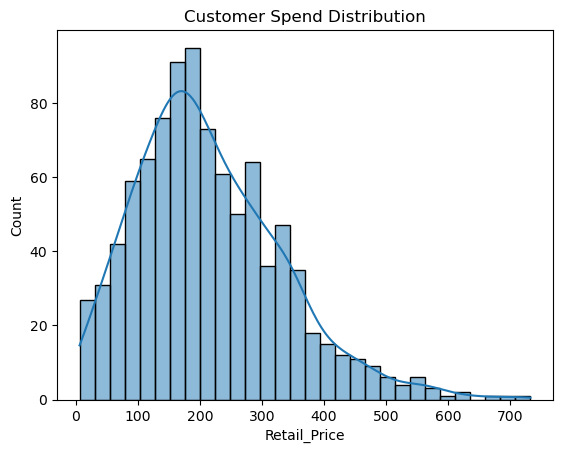

In [44]:
# 3. Customer Segmentation
customer_spend = df.groupby('CustomerID')['Retail_Price'].sum()
sns.histplot(customer_spend, bins=30, kde=True)
plt.title("Customer Spend Distribution")
plt.show()

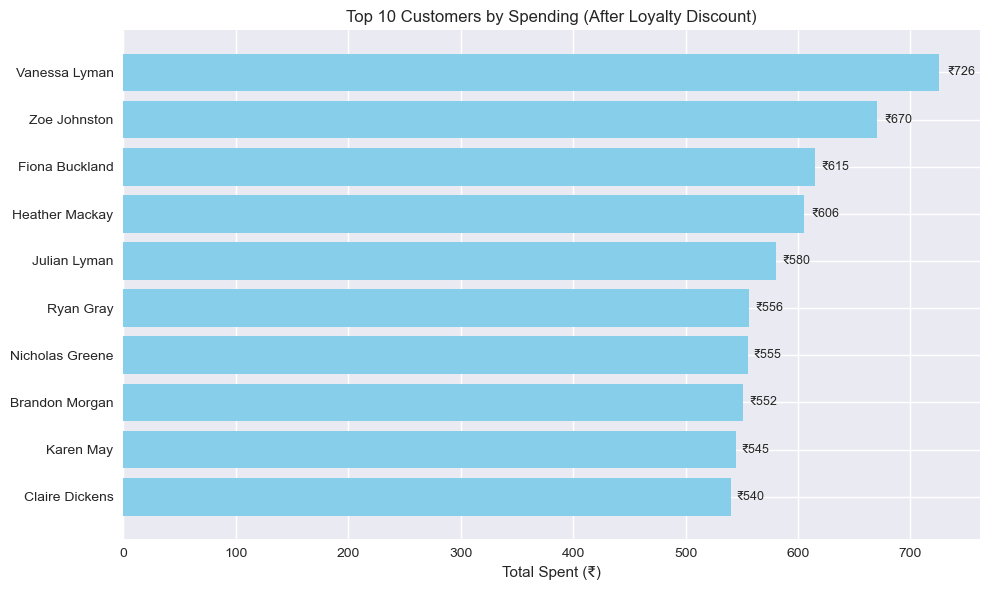

In [51]:
# A bar chart to show Top 10 customers by spending (After Loyalty Discount).
df = pd.read_csv("C:/Users/Hp/Downloads/P9-OLTP.csv")  
# Assuming you already have your dataframe 'df' and top_customers calculated
df['Net_Price'] = df['Retail_Price'] * (1 - df['Loyalty_Discount'])
top_customers = df.groupby(['CustomerID', 'Name', 'Surname']).agg({
    'Net_Price': 'sum',
    'TransactionID': 'count'
}).reset_index().rename(columns={'Net_Price': 'Total_Spent', 'TransactionID': 'Transaction_Count'})
# Sort by spending (descending for visualization clarity)
top_customers = top_customers.sort_values('Total_Spent', ascending=False).head(10)
# Create a full name column for labels
top_customers['FullName'] = top_customers['Name'] + " " + top_customers['Surname']

# --- Visualization ---
plt.style.use('seaborn-v0_8')
fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(top_customers['FullName'], top_customers['Total_Spent'], color='skyblue')

# Annotate bars with spending values
for bar in bars:
    width = bar.get_width()
    ax.text(width + (width * 0.01), bar.get_y() + bar.get_height()/2,
            f'₹{width:,.0f}', va='center', fontsize=9)

ax.set_xlabel("Total Spent (₹)")
ax.set_title("Top 10 Customers by Spending (After Loyalty Discount)")
plt.gca().invert_yaxis()  # Highest spender at the top
plt.tight_layout()
plt.show()

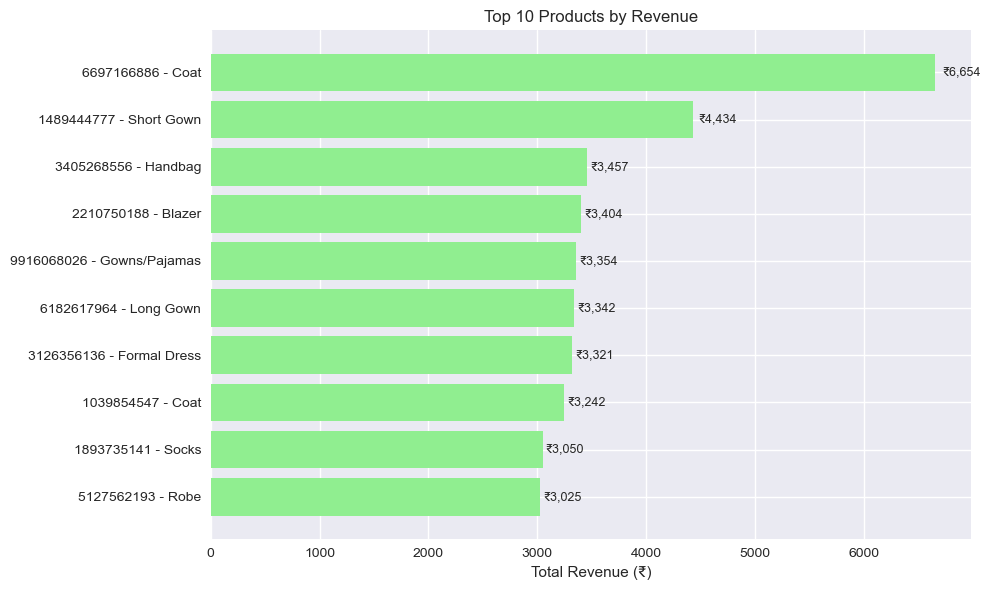

In [52]:
# A  bar chart to show top 10 Products by revenue.
top_products = df.groupby(['Item No.', 'Description']).agg({
    'Net_Price': 'sum',
    'TransactionID': 'count',
    'Retail_Price': 'mean'
}).rename(columns={
    'Net_Price': 'Total_Revenue',
    'TransactionID': 'Units_Sold',
    'Retail_Price': 'Avg_Price'
})
# Sort by revenue (descending for clarity)
top_products = top_products.sort_values('Total_Revenue', ascending=False).head(10)
# Create a label combining Item No. and Description
top_products['Label'] = top_products.index.get_level_values('Item No.').astype(str) + " - " + top_products.index.get_level_values('Description')

# --- Visualization ---
plt.style.use('seaborn-v0_8')
fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.barh(top_products['Label'], top_products['Total_Revenue'], color='lightgreen')

# Annotate bars with revenue values
for bar in bars:
    width = bar.get_width()
    ax.text(width + (width * 0.01), bar.get_y() + bar.get_height()/2,
            f'₹{width:,.0f}', va='center', fontsize=9)

ax.set_xlabel("Total Revenue (₹)")
ax.set_title("Top 10 Products by Revenue")
plt.gca().invert_yaxis()  # Highest revenue at the top
plt.tight_layout()
plt.show()

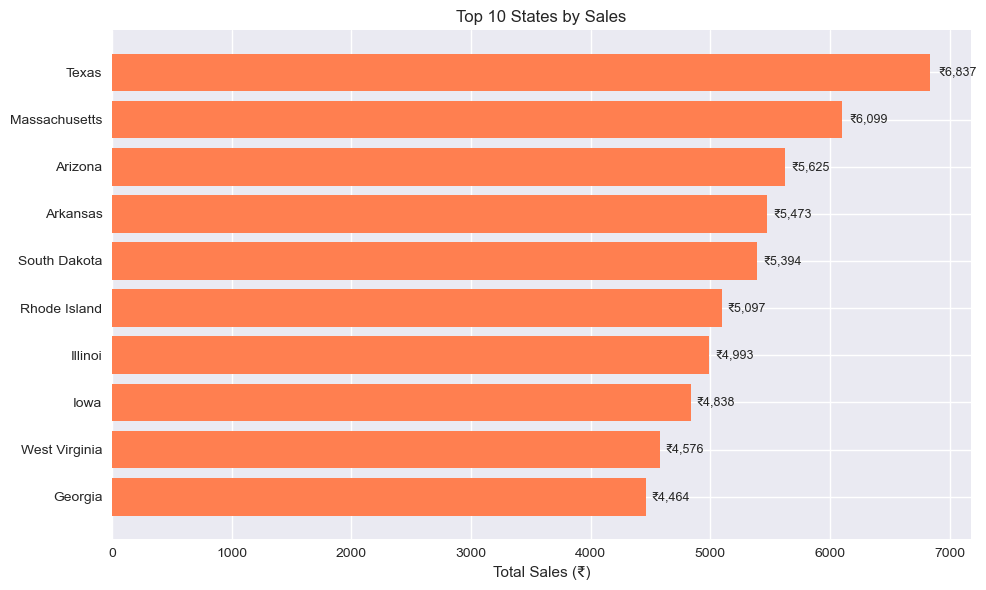

In [56]:
# A bar chart to show Top 10 States by Sales 
top_states = df.groupby('Shipping_State').agg({
    'Net_Price': 'sum',
    'TransactionID': 'count',
    'CustomerID': 'nunique'
}).rename(columns={
    'Net_Price': 'Total_Sales',
    'TransactionID': 'Transaction_Count',
    'CustomerID': 'Unique_Customers'
})
# Sort by sales (descending for clarity)
top_states = top_states.sort_values('Total_Sales', ascending=False).head(10)

# --- Visualization ---
plt.style.use('seaborn-v0_8')
fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.barh(top_states.index, top_states['Total_Sales'], color='coral')

# Annotate bars with sales values
for bar in bars:
    width = bar.get_width()
    ax.text(width + (width * 0.01), bar.get_y() + bar.get_height()/2,
            f'₹{width:,.0f}', va='center', fontsize=9)

ax.set_xlabel("Total Sales (₹)")
ax.set_title("Top 10 States by Sales")
plt.gca().invert_yaxis()  # Highest sales at the top
plt.tight_layout()
plt.show()

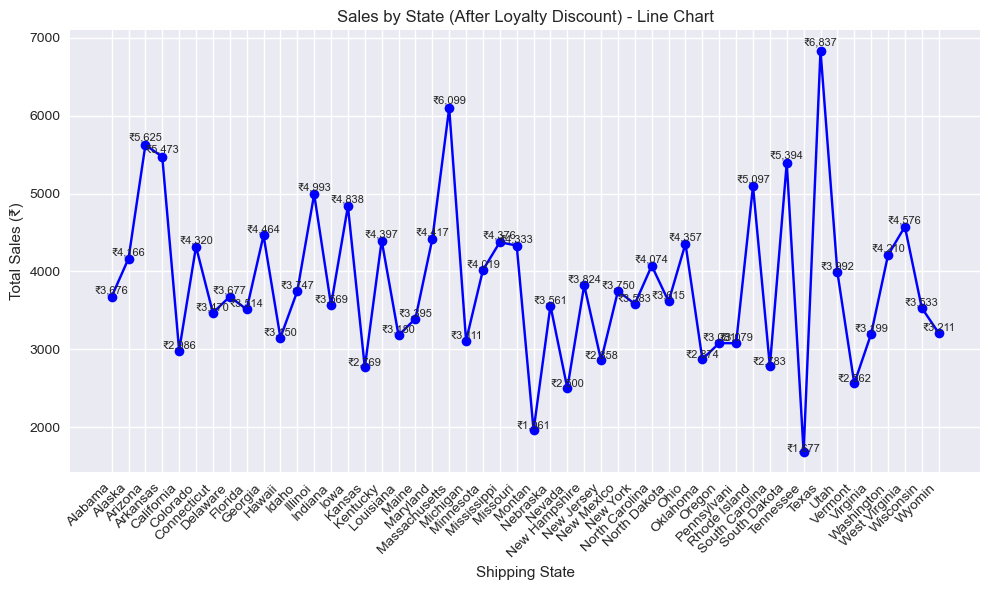

In [4]:
# A line chart showing total sales by state (after loyalty discount) to spot regional trends.
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("C:/Users/Hp/Downloads/P9-OLTP.csv")  
df['Net_Price'] = df['Retail_Price'] * (1 - df['Loyalty_Discount'])
# Group by Shipping_State and sum Net_Price
state_sales = df.groupby('Shipping_State')['Net_Price'].sum().reset_index()

# --- Visualization ---
plt.style.use('seaborn-v0_8')
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(state_sales['Shipping_State'], state_sales['Net_Price'],
        marker='o', linestyle='-', color='blue')

# Add labels and title
plt.xticks(rotation=45, ha='right')
ax.set_xlabel("Shipping State")
ax.set_ylabel("Total Sales (₹)")
ax.set_title("Sales by State (After Loyalty Discount) - Line Chart")

# Annotate points with values
for i, val in enumerate(state_sales['Net_Price']):
    ax.text(i, val + (val * 0.01), f'₹{val:,.0f}', ha='center', fontsize=8)

plt.tight_layout()
plt.show()

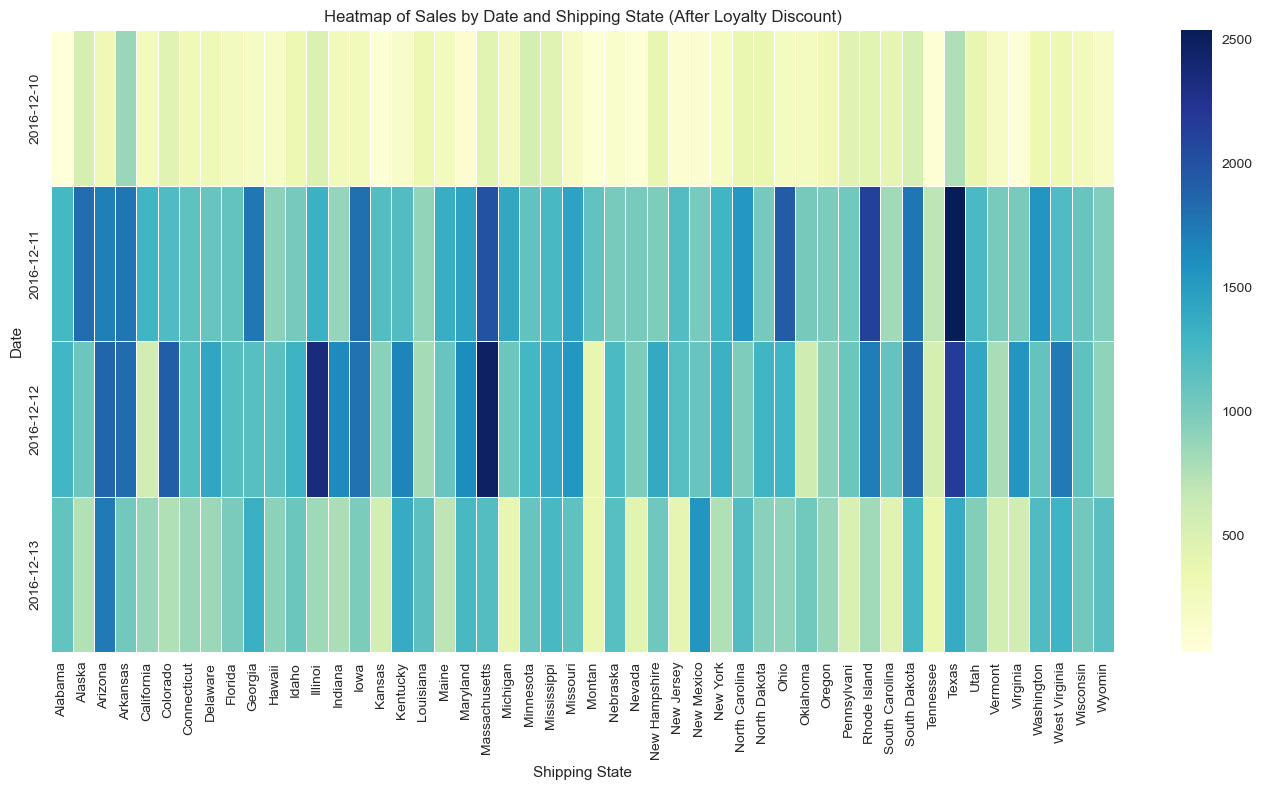

In [8]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("C:/Users/Hp/Downloads/P9-OLTP.csv")
df['Date'] = pd.to_datetime(df['Date'], dayfirst = True)
# Calculate Net Price after loyalty discount
df['Net_Price'] = df['Retail_Price'] * (1 - df['Loyalty_Discount'])
# Extract Date (day-level) and Hour for time dimension
df['Day'] = df['Date'].dt.date
df['Hour'] = df['Date'].dt.hour
# --- Create Pivot Table: Sales by Day × Shipping_State ---
pivot_table = df.pivot_table(
    index='Day',
    columns='Shipping_State',
    values='Net_Price',
    aggfunc='sum',
    fill_value=0
)

# --- Heatmap Visualization ---
plt.figure(figsize=(14, 8))
sns.heatmap(pivot_table, cmap="YlGnBu", linewidths=0.5)

plt.title("Heatmap of Sales by Date and Shipping State (After Loyalty Discount)")
plt.xlabel("Shipping State")
plt.ylabel("Date")
plt.tight_layout()
plt.show()

In [25]:
print(" ======= CONCLUSION ======== ")
print("This analysis provides a clear view of customer behavior, product performance, and regional trends, enabling data-driven decisions for growth.")
print (" ================================================================================================================= ")

 ======= CONCLUSION ======== 
This analysis provides a clear view of customer behavior, product performance, and regional trends, enabling data-driven decisions for growth.
